In [1]:
# Cell 1 — Imports
import json
import time
import requests
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyinaturalist import get_taxa, get_observations
from tqdm import tqdm
from PIL import Image
import boto3
from dotenv import load_dotenv
import os

In [9]:
load_dotenv()

True

In [10]:
IMAGES_PER_SPECIES = 500
DOWNLOAD_DIR = Path("/Volumes/kaggle/inat_fish")
DOWNLOADED_IDS_FILE = DOWNLOAD_DIR / "downloaded_ids.json"
MAX_WORKERS = 20

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('AISTOR_ENDPOINT'),
    aws_access_key_id=os.getenv('AISTOR_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('AISTOR_SECRET_KEY')
)

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 2 — Query Pacific/freshwater fish from iNaturalist
results = get_taxa(
    taxon_id=47178,   # Actinopterygii - ray-finned fish
    place_id=59,      # California coast
    rank="species",
    per_page=200,
    order_by="observations_count",
    order="desc"
)

qualified = []
for taxon in results['results']:
    name = taxon['name']
    common = taxon.get('preferred_common_name', 'no common name')
    obs_count = taxon.get('observations_count', 0)
    taxon_id = taxon.get('id')
    if obs_count >= 500:
        qualified.append({
            'name': name,
            'common': common,
            'count': obs_count,
            'taxon_id': taxon_id
        })

print(f"Total qualified species: {len(qualified)}")

Total qualified species: 200


In [4]:
# Cell 3 — Add Pacific mackerel species manually
extra_species = [
    {'name': 'Scomber japonicus', 'common': 'Pacific Chub Mackerel', 'count': 607, 'taxon_id': 69840},
    {'name': 'Trachurus symmetricus', 'common': 'Pacific Jack Mackerel', 'count': 300, 'taxon_id': 114274},
]
qualified.extend(extra_species)
print(f"Total species with mackerel: {len(qualified)}")

Total species with mackerel: 202


In [5]:
# Cell 4 — Filter to species with common names only
final_species = [s for s in qualified if s['common'] != 'no common name']
print(f"Final species count: {len(final_species)}")
for i, s in enumerate(final_species, 1):
    print(f"{i:3}. {s['common']:40} {s['name']:35} {s['count']:,}")

Final species count: 202
  1. Bluegill                                 Lepomis macrochirus                 59,382
  2. Largemouth Bass                          Micropterus nigricans               39,949
  3. European Carp                            Cyprinus carpio                     32,854
  4. Rainbow Trout                            Oncorhynchus mykiss                 24,844
  5. Amur Carp                                Cyprinus rubrofuscus                22,041
  6. Western Mosquitofish                     Gambusia affinis                    19,986
  7. Green Sunfish                            Lepomis cyanellus                   19,692
  8. Pumpkinseed                              Lepomis gibbosus                    18,016
  9. Smallmouth Bass                          Micropterus dolomieu                17,332
 10. Bluefin Leatherjacket                    Thamnaconus degeni                  17,228
 11. Goldfish                                 Carassius auratus                   16,

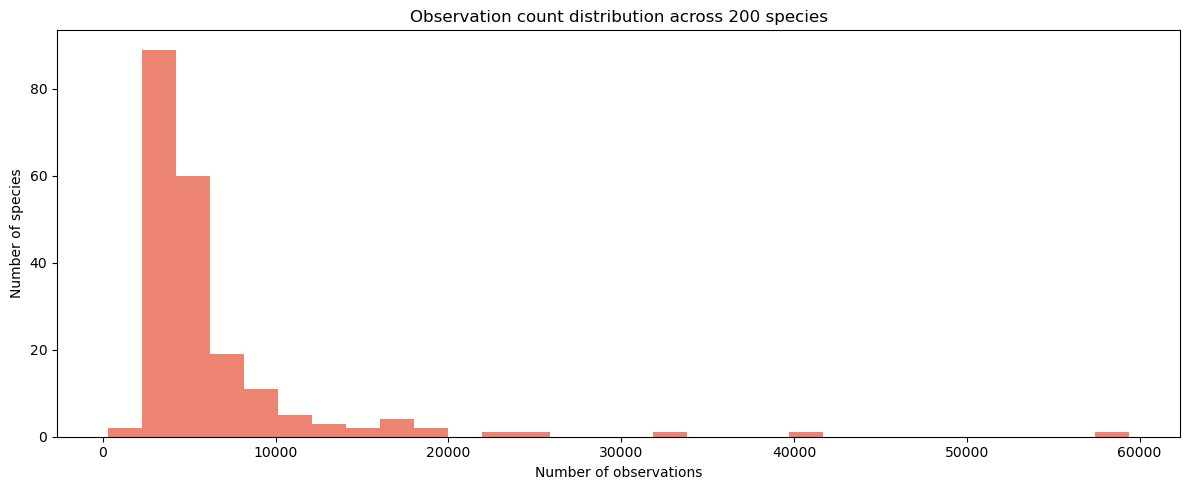

Min observations: 300
Max observations: 59382
Median observations: 4459
Species with 1000+: 200
Species with 2000+: 200


In [6]:
# Cell 5 — Distribution plot
counts = [s['count'] for s in qualified]
plt.figure(figsize=(12, 5))
plt.hist(counts, bins=30, color='#e8664d', alpha=0.8)
plt.xlabel('Number of observations')
plt.ylabel('Number of species')
plt.title('Observation count distribution across 200 species')
plt.tight_layout()
plt.savefig('../outputs/species_distribution.png')
plt.show()

print(f"Min observations: {min(counts)}")
print(f"Max observations: {max(counts)}")
print(f"Median observations: {np.median(counts):.0f}")
print(f"Species with 1000+: {sum(1 for c in counts if c >= 1000)}")
print(f"Species with 2000+: {sum(1 for c in counts if c >= 2000)}")

In [7]:
# Cell 6 — Download helpers
def load_downloaded_ids():
    if DOWNLOADED_IDS_FILE.exists():
        with open(DOWNLOADED_IDS_FILE) as f:
            return set(json.load(f))
    return set()

def save_downloaded_ids(ids):
    with open(DOWNLOADED_IDS_FILE, 'w') as f:
        json.dump(list(ids), f)

def download_image(args):
    obs_id, url, filepath = args
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(filepath, 'wb') as f:
                f.write(r.content)
            return obs_id, True
    except Exception:
        pass
    return obs_id, False

In [ ]:
# Cell 7 — Main download loop
downloaded_ids = load_downloaded_ids()
print(f"Loaded {len(downloaded_ids)} previously downloaded IDs")

for species in final_species:
    name = species['name']
    common = species['common']
    species_dir = DOWNLOAD_DIR / name.replace(' ', '_')
    species_dir.mkdir(exist_ok=True)

    existing = list(species_dir.glob("*.jpg"))
    if len(existing) >= IMAGES_PER_SPECIES:
        print(f"✓ Skipping {common} — already have {len(existing)} images")
        continue

    needed = IMAGES_PER_SPECIES - len(existing)

    # Collect download tasks
    tasks = []
    page = 1
    while len(tasks) < needed + 50:
        obs = get_observations(
            taxon_name=name,
            quality_grade="research",
            photos=True,
            per_page=200,
            page=page
        )
        if not obs['results']:
            break
        for o in obs['results']:
            obs_id = str(o['id'])
            if obs_id in downloaded_ids or not o.get('photos'):
                continue
            photo_url = o['photos'][0]['url'].replace('square', 'medium')
            filepath = species_dir / f"{obs_id}.jpg"
            if not filepath.exists():
                tasks.append((obs_id, photo_url, filepath))
        page += 1

    # Download concurrently with progress bar
    count = len(existing)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(download_image, task): task for task in tasks}
        with tqdm(total=needed, desc=f"{common[:35]:35}", unit="img") as pbar:
            for future in as_completed(futures):
                if count >= IMAGES_PER_SPECIES:
                    break
                obs_id, success = future.result()
                if success:
                    downloaded_ids.add(obs_id)
                    count += 1
                    pbar.update(1)

    save_downloaded_ids(downloaded_ids)
    print(f"  ✓ {common}: {count}/{IMAGES_PER_SPECIES} images")

print("\nAll done!")
print(f"Total species: {len(list(DOWNLOAD_DIR.iterdir())) - 1}")
print(f"Total images: {len(list(DOWNLOAD_DIR.rglob('*.jpg')))}")

In [8]:
# Cell 8 — Image quality audit (concurrent)
def audit_image(img_path):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            if w < 100 or h < 100:
                return img_path, f"too small: {w}x{h}"
            if img.mode not in ['RGB', 'RGBA']:
                return img_path, f"bad mode: {img.mode}"
    except Exception as e:
        return img_path, f"corrupted: {e}"
    return img_path, None

In [ ]:
# Cell 8 — Image quality audit (concurrent)
print("Scanning for images...")
all_images = list(DOWNLOAD_DIR.rglob("*.jpg"))
print(f"Found {len(all_images)} images — starting audit...")

issues = []
checked = 0
removed = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(audit_image, img): img for img in all_images}
    with tqdm(
        total=len(all_images),
        desc="Auditing",
        unit="img",
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] issues: {postfix}"
    ) as pbar:
        for future in as_completed(futures):
            img_path, reason = future.result()
            checked += 1
            if reason:
                issues.append((img_path, reason))
            pbar.set_postfix_str(f"{len(issues)} issues found")
            pbar.update(1)

print(f"\nAudit complete — {checked} images checked")
print(f"Total issues found: {len(issues)}")

for path, reason in issues[:20]:
    print(f"  {reason} — {path.name}")

if issues:
    for path, reason in issues:
        path.unlink()
        removed += 1
    print(f"\nRemoved {removed} bad images")
    print(f"Clean images remaining: {len(all_images) - removed}")
else:
    print("All images passed quality check ✓")

In [11]:
# Cell 9 — Create AIStor bucket and upload dataset
bucket = 'fish-classifier-expanded'
checks = {}

# Check ListBucket
try:
    s3.list_objects_v2(Bucket=bucket, MaxKeys=1)
    checks['ListBucket'] = '✓'
except Exception as e:
    checks['ListBucket'] = f'✗ {e}'

# Check PutObject
try:
    s3.put_object(Bucket=bucket, Key='_test/test.txt', Body=b'test')
    checks['PutObject'] = '✓'
except Exception as e:
    checks['PutObject'] = f'✗ {e}'

# Check GetObject
try:
    s3.get_object(Bucket=bucket, Key='_test/test.txt')
    checks['GetObject'] = '✓'
except Exception as e:
    checks['GetObject'] = f'✗ {e}'

# Check DeleteObject
try:
    s3.delete_object(Bucket=bucket, Key='_test/test.txt')
    checks['DeleteObject'] = '✓'
except Exception as e:
    checks['DeleteObject'] = f'✗ {e}'

print(f"Bucket: {bucket}")
print(f"Endpoint: {os.getenv('AISTOR_ENDPOINT')}")
print()
for permission, status in checks.items():
    print(f"  {permission:20} {status}")

all_pass = all('✓' in v for v in checks.values())
print()
print("✓ All permissions OK — ready to upload" if all_pass else "✗ Fix permissions before uploading")

Bucket: fish-classifier-expanded
Endpoint: http://192.168.0.40:8900

  ListBucket           ✓
  PutObject            ✓
  GetObject            ✓
  DeleteObject         ✓

✓ All permissions OK — ready to upload


In [13]:
# Cell 10 — Upload images to AIStor concurrently (skip existing)
def upload_image(args):
    img_path, bucket, key = args
    try:
        s3.upload_file(str(img_path), bucket, key)
        return key, True
    except Exception as e:
        return key, False

print("Scanning images for upload...")
all_images = [p for p in DOWNLOAD_DIR.rglob("*.jpg")]
print(f"Found {len(all_images)} images locally")

# Fetch existing keys from AIStor
print("Fetching existing keys from AIStor...")
existing_keys = set()
paginator = s3.get_paginator('list_objects_v2')
with tqdm(desc="Scanning AIStor", unit=" pages") as pbar:
    for page in paginator.paginate(Bucket='fish-classifier-expanded', Prefix='raw/'):
        for obj in page.get('Contents', []):
            existing_keys.add(obj['Key'])
        pbar.update(1)
print(f"Found {len(existing_keys):,} already uploaded")

# Build tasks — skip existing
tasks = []
for img_path in all_images:
    species = img_path.parent.name
    key = f"raw/{species}/{img_path.name}"
    if key not in existing_keys:
        tasks.append((img_path, 'fish-classifier-expanded', key))

print(f"Skipping {len(all_images) - len(tasks):,} already uploaded")
print(f"Uploading {len(tasks):,} new images...")

failed = []
uploaded = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(upload_image, task): task for task in tasks}
    with tqdm(
        total=len(tasks),
        desc="Uploading",
        unit="img",
        colour="green",
        bar_format="{l_bar}{bar:30}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {rate_fmt} | failed: {postfix}"
    ) as pbar:
        for future in as_completed(futures):
            key, success = future.result()
            if success:
                uploaded += 1
            else:
                failed.append(key)
            pbar.set_postfix_str(f"{len(failed)}")
            pbar.update(1)

print(f"\n{'='*50}")
print(f"Upload complete")
print(f"{'='*50}")
print(f"Total local:  {len(all_images):,}")
print(f"Skipped:      {len(existing_keys):,}")
print(f"Uploaded:     {uploaded:,}")
print(f"Failed:       {len(failed):,}")
if failed:
    print(f"\nFirst 10 failed keys:")
    for k in failed[:10]:
        print(f"  {k}")

Scanning images for upload...
Found 180796 images locally
Fetching existing keys from AIStor...


Scanning AIStor: 181 pages [00:12, 14.42 pages/s]


Found 180,796 already uploaded
Skipping 180,796 already uploaded
Uploading 0 new images...


Uploading: |                              | 0/0 [00:00<?] ?img/s | failed: 


Upload complete
Total local:  180,796
Skipped:      180,796
Uploaded:     0
Failed:       0
